In [2]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
# Drop rows with missing Customer ID
df.dropna(subset=['Customer ID'], inplace=True)


df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price per Unit'] = df['Price per Unit'].fillna(df['Price per Unit'].median())



In [8]:

df['Total Amount'] = df['Quantity'] * df['Price per Unit']


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
latest_date = df['Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (latest_date - x.max()).days,   # Recency
    'Transaction ID':'count',                         # Frequency
    'Total Amount':'sum'                              # Monetary
})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


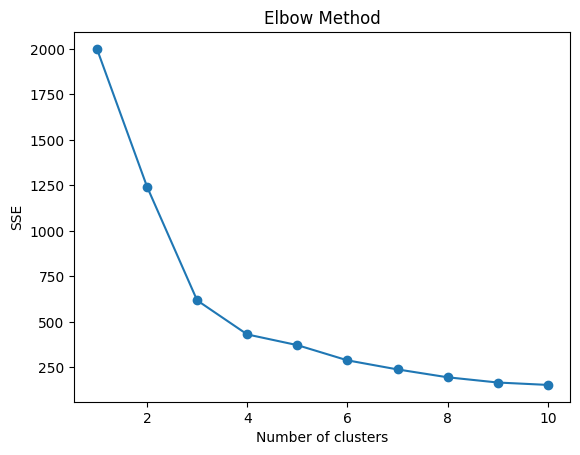

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(1,11), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()


In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
CUST001,38,1,150,1
CUST002,308,1,1000,3
CUST003,353,1,30,0
CUST004,225,1,500,0
CUST005,240,1,100,0


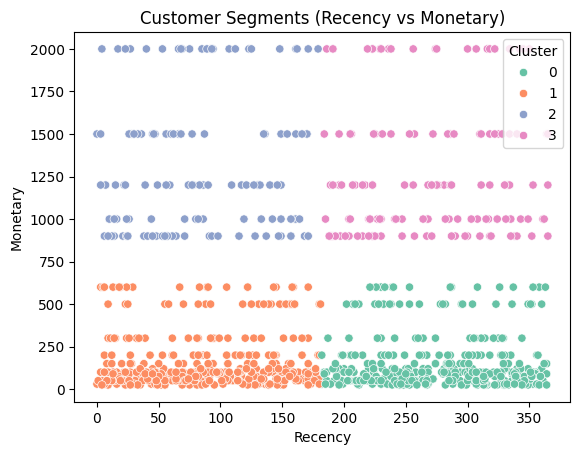

In [15]:
import seaborn as sns

sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='Set2')
plt.title('Customer Segments (Recency vs Monetary)')
plt.show()


In [16]:
cluster_profile = rfm.groupby('Cluster').mean()
cluster_profile


,Recency,Frequency,Monetary
Cluster,,,
0,273.076087,1.0,148.138587
1,90.622283,1.0,160.013587
2,83.935484,1.0,1313.709677
3,269.521429,1.0,1283.571429


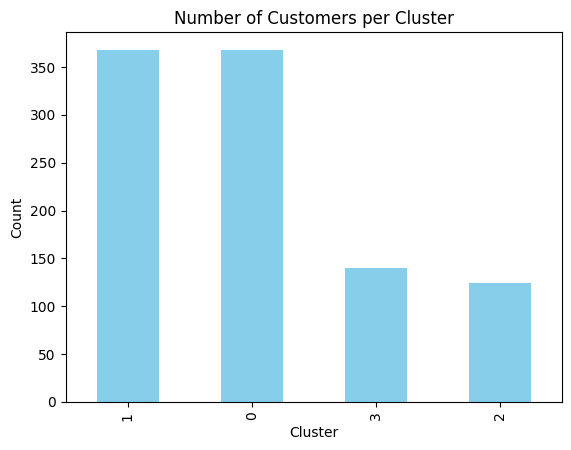

In [17]:
rfm['Cluster'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()
